<a href="https://colab.research.google.com/github/AnikKushwaha/AnikKushwaha/blob/master/Jobwork3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install deepface opencv-python matplotlib seaborn scikit-learn


In [2]:
import os
import numpy as np
from deepface import DeepFace
from sklearn.datasets import fetch_lfw_people
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from joblib import dump, load


In [5]:
lfw = fetch_lfw_people(min_faces_per_person=50, resize=0.5)

images = lfw.images
labels = lfw.target
label_names = lfw.target_names

print("Dataset Loaded ")
print("Total images:", len(images))
print("People:", len(label_names))


Dataset Loaded 
Total images: 1560
People: 12


In [6]:
embeddings = []
y_labels = []

for i in range(len(images)):
    img = images[i]
    rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    try:
        embedding = DeepFace.represent(rgb, model_name="Facenet512", enforce_detection=False)
        embeddings.append(embedding[0]["embedding"])
        y_labels.append(labels[i])
    except:
        continue

embeddings = np.array(embeddings)
y_labels = np.array(y_labels)

print("Embeddings Created — Total:", len(embeddings))


Embeddings Created — Total: 1560


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, y_labels, test_size=0.2, random_state=42
)


In [8]:
clf = SVC(kernel='linear', probability=True)
clf.fit(X_train, y_train)

dump(clf, "face_model.joblib")
dump(label_names, "labels.joblib")

print("Model Training Completed ")


Model Training Completed 



 Accuracy: 34.29 %

Classification Report:
                   precision    recall  f1-score   support

     Ariel Sharon       0.00      0.00      0.00        11
     Colin Powell       0.00      0.00      0.00        55
  Donald Rumsfeld       0.00      0.00      0.00        25
    George W Bush       0.34      1.00      0.51       107
Gerhard Schroeder       0.00      0.00      0.00        21
      Hugo Chavez       0.00      0.00      0.00        14
   Jacques Chirac       0.00      0.00      0.00         7
    Jean Chretien       0.00      0.00      0.00        12
    John Ashcroft       0.00      0.00      0.00        12
Junichiro Koizumi       0.00      0.00      0.00         8
  Serena Williams       0.00      0.00      0.00         7
       Tony Blair       0.00      0.00      0.00        33

         accuracy                           0.34       312
        macro avg       0.03      0.08      0.04       312
     weighted avg       0.12      0.34      0.18       312



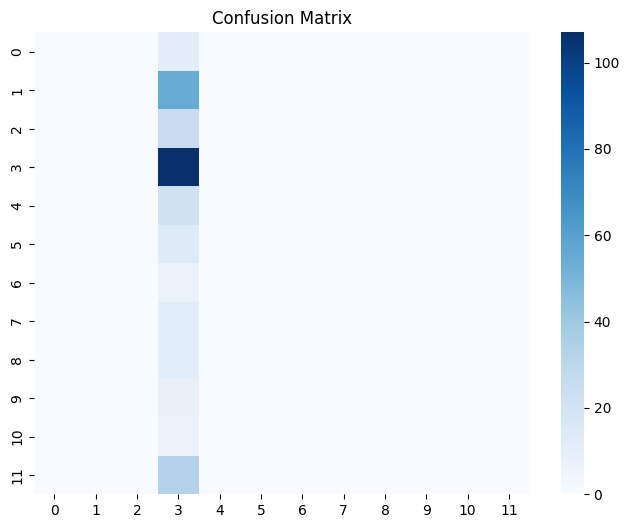

In [9]:
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("\n Accuracy:", round(acc*100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


In [10]:
idx = np.random.randint(len(X_test))
true_person = label_names[y_test[idx]]
pred_person = label_names[y_pred[idx]]

print("True:", true_person)
print("Predicted:", pred_person)


True: George W Bush
Predicted: George W Bush
